In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

### Linear

In [47]:
distances = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
times = torch.tensor([[5.0], [10.0], [15.0], [20.0]], dtype=torch.float32)

In [48]:
model = nn.Sequential(nn.Linear(1,1))

# 
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training
for epoch in range(500):
    optimizer.zero_grad()
    output = model(distances)
    loss = loss_function(output, times)
    loss.backward() # Back Propogation
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.515618085861206
Epoch 100: Loss = 0.3820394277572632
Epoch 150: Loss = 0.2830670475959778
Epoch 200: Loss = 0.20973503589630127
Epoch 250: Loss = 0.15540021657943726
Epoch 300: Loss = 0.11514215916395187
Epoch 350: Loss = 0.08531315624713898
Epoch 400: Loss = 0.06321153789758682
Epoch 450: Loss = 0.04683581367135048
Epoch 500: Loss = 0.03470252454280853


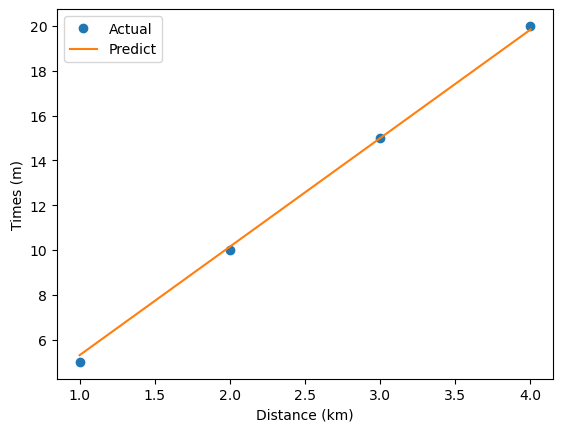

In [49]:
def plot_result(model, distances, times):
    model.eval()

    with torch.no_grad():
        prediction = model(distances)

    plt.plot(distances, times, label="Actual", linestyle="None", marker="o")
    plt.plot(distances, prediction, label="Predict")
    plt.xlabel("Distance (km)")
    plt.ylabel("Times (m)")
    plt.legend()
    plt.show()

plot_result(model, distances, times)

In [50]:
# Inspection 
layer = model[0]
weight = layer.weight
bias = layer.bias 
print(f"weight: {weight}, bias: {bias}")

weight: Parameter containing:
tensor([[4.8454]], requires_grad=True), bias: Parameter containing:
tensor([0.4545], requires_grad=True)


### Non Linear

In [51]:
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

In [52]:
distances_norm = (distances - distances.mean()) / distances.std()
times_norm = (times - times.mean()) / distances.std()

In [53]:
model = nn.Sequential(
    nn.Linear(1,3),
    nn.ReLU(),
    nn.Linear(3,1)
)

loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(3000):
    optimizer.zero_grad()
    output = model(distances_norm)
    loss = loss_function(output, times_norm)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 13.212143898010254
Epoch 100: Loss = 8.858646392822266
Epoch 150: Loss = 6.514654159545898
Epoch 200: Loss = 5.12599515914917
Epoch 250: Loss = 4.237954616546631
Epoch 300: Loss = 3.5987560749053955
Epoch 350: Loss = 3.108551025390625
Epoch 400: Loss = 2.647258758544922
Epoch 450: Loss = 2.2065935134887695
Epoch 500: Loss = 1.8010228872299194
Epoch 550: Loss = 1.4499801397323608
Epoch 600: Loss = 1.1672649383544922
Epoch 650: Loss = 0.9497910737991333
Epoch 700: Loss = 0.786094605922699
Epoch 750: Loss = 0.6638479232788086
Epoch 800: Loss = 0.5644707083702087
Epoch 850: Loss = 0.4854923188686371
Epoch 900: Loss = 0.42346101999282837
Epoch 950: Loss = 0.3697882890701294
Epoch 1000: Loss = 0.32393011450767517
Epoch 1050: Loss = 0.2876286208629608
Epoch 1100: Loss = 0.259208619594574
Epoch 1150: Loss = 0.23381705582141876
Epoch 1200: Loss = 0.21125373244285583
Epoch 1250: Loss = 0.19324347376823425
Epoch 1300: Loss = 0.17874394357204437
Epoch 1350: Loss = 0.16698466241359

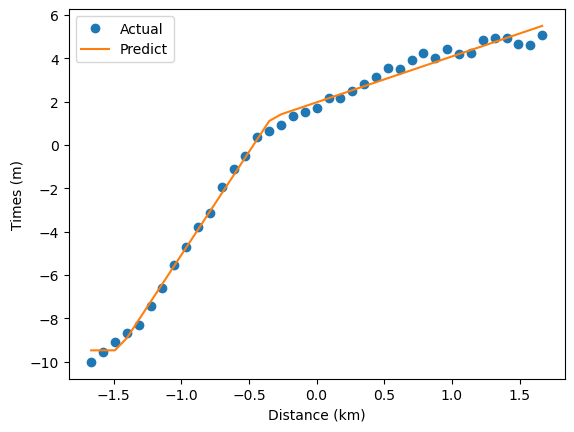

In [54]:
plot_result(model, distances_norm, times_norm)